In [26]:
# REFACTORED MOTOR LEARNING ANALYSIS PIPELINE
# ============================================
# This refactored version consolidates redundant code, improves organization,
# and creates a cleaner class hierarchy

import os
os.environ['OMP_NUM_THREADS'] = '1'

from abc import ABC, abstractmethod
from dataclasses import dataclass, field
from pathlib import Path
from typing import List, Dict, Tuple, Optional, Union, Any
import json
import pickle
import warnings
from datetime import datetime
from collections import defaultdict

import numpy as np
import pandas as pd
from scipy.stats import pearsonr, mannwhitneyu, gaussian_kde, ttest_ind, f_oneway
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Statistical packages
import pingouin as pg
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')

In [28]:
# ==============================================================================
# CONFIGURATION AND DATA STRUCTURES
# ==============================================================================

@dataclass
class AnalysisConfig:
    """Centralized configuration for all analysis parameters."""
    
    # Directories
    base_output_dir: Path = Path('motor_learning_output')
    
    # Thresholds
    min_complete_strides: int = 20
    motor_noise_strides: int = 20
    motor_noise_threshold: float = 0.3
    success_rate_threshold: float = 0.68
    target_size_threshold: float = 0.31
    max_strides_threshold: int = 415
    
    # Visualization
    figure_dpi: int = 300
    alpha_level: float = 0.05
    age_bins: List[int] = field(default_factory=lambda: [7, 10, 13, 16, 18])
    age_labels: List[str] = field(default_factory=lambda: ['7-10', '10-13', '13-16', '16-18'])
    
    # Trial mappings
    trial_type_mapping: Dict[str, str] = field(default_factory=lambda: {
        'primer': 'vis1',
        'trial': 'invis',
        'vis': 'vis2',
        'pref': 'pref'
    })
    
    def __post_init__(self):
        """Create directory structure."""
        self.figures_dir = self.base_output_dir / 'figures'
        self.individual_plots_dir = self.figures_dir / 'individual_plots'
        self.population_plots_dir = self.figures_dir / 'population_plots'
        self.statistical_plots_dir = self.figures_dir / 'statistical_plots'
        self.reports_dir = self.base_output_dir / 'reports'
        self.exports_dir = self.base_output_dir / 'exports'
        self.processed_data_dir = self.base_output_dir / 'processed_data'
        
        # Create all directories
        for directory in [self.figures_dir, self.individual_plots_dir, 
                         self.population_plots_dir, self.statistical_plots_dir,
                         self.reports_dir, self.exports_dir, self.processed_data_dir]:
            directory.mkdir(parents=True, exist_ok=True)
        
        self.processed_data_file = self.processed_data_dir / 'processed_data.pkl'

@dataclass
class SubjectData:
    """Container for individual subject data."""
    subject_id: str
    metadata: Dict[str, Any]
    trial_data: Dict[str, Dict[str, Any]]
    
    @property
    def age(self) -> float:
        """Get age in years."""
        return self.metadata.get('age_months', np.nan) / 12

@dataclass
class TrialData:
    """Container for trial data."""
    data: pd.DataFrame
    anomalies: Dict[int, List[str]]
    trial_type: str
    
    @property
    def is_valid(self) -> bool:
        """Check if trial data is valid."""
        return self.data is not None and not self.data.empty

In [30]:
# ==============================================================================
# BASE CLASSES
# ==============================================================================

class BaseProcessor(ABC):
    """Base class for all data processors."""
    
    def __init__(self, config: AnalysisConfig, debug: bool = True):
        self.config = config
        self.debug = debug
    
    def log(self, message: str, level: str = "info"):
        """Logging helper."""
        if self.debug:
            symbols = {"info": "📊", "warning": "⚠️", "error": "❌", "success": "✓"}
            print(f"{symbols.get(level, '•')} {message}")

class BaseVisualizer(ABC):
    """Base class for all visualizers."""
    
    def __init__(self, config: AnalysisConfig):
        self.config = config
        self.colors = {
            'primary': '#667eea',
            'secondary': '#764ba2',
            'success': '#28a745',
            'warning': '#ffc107',
            'danger': '#dc3545',
            'vis1': '#1f77b4',
            'invis': '#ff7f0e',
            'vis2': '#2ca02c'
        }
    
    def run_repeated_measures_anova(self) -> Dict:
        """Run repeated measures ANOVA using pingouin."""
        # Prepare long-format data
        long_rows = []
        
        for _, row in self.filtered_df.iterrows():
            subject_id = row.name
            for col in self.filtered_df.columns:
                if '_sr_' in col and '_const' in col:
                    parts = col.split('_')
                    trial_type = parts[0]
                    condition = parts[2]
                    
                    if pd.notna(row[col]):
                        long_rows.append({
                            'subject': subject_id,
                            'trial_type': trial_type,
                            'condition': condition,
                            'success_rate': row[col],
                            'age': row.get('age', np.nan),
                            'motor_noise': row.get('mot_noise', np.nan)
                        })
        
        df_long = pd.DataFrame(long_rows).dropna()
        
        if df_long.empty:
            return {'error': 'No valid data for analysis'}
        
        results = {}
        
        # Main effect of trial type
        if len(df_long['trial_type'].unique()) > 1:
            aov_trial = pg.rm_anova(data=df_long, dv='success_rate', 
                                   within='trial_type', subject='subject', detailed=True)
            results['trial_type_effect'] = {
                'F': aov_trial['F'].iloc[0],
                'p_value': aov_trial['p-unc'].iloc[0],
                'effect_size': aov_trial['ng2'].iloc[0]
            }
        
        return results

In [32]:
# ==============================================================================
# VISUALIZATION COMPONENTS
# ==============================================================================

class PopulationVisualizer(BaseVisualizer):
    """Handles population-level visualizations."""
    
    def __init__(self, metrics_df: pd.DataFrame, config: AnalysisConfig):
        super().__init__(config)
        self.metrics_df = metrics_df
        
        # Apply motor noise filter
        if 'mot_noise' in metrics_df.columns:
            self.filtered_df = metrics_df[metrics_df['mot_noise'] <= config.motor_noise_threshold]
        else:
            self.filtered_df = metrics_df
    
    def plot_age_vs_success_rates(self) -> Path:
        """Plot age vs success rates by trial/condition with motor noise coloring."""
        trials = ['vis1', 'invis', 'vis2']
        conditions = ['max', 'min']
        has_motor_noise = 'mot_noise' in self.filtered_df.columns
        
        fig, axes = plt.subplots(len(trials), len(conditions), figsize=(12, 4*len(trials)))
        if len(trials) == 1:
            axes = axes.reshape(1, -1)
        
        for i, trial in enumerate(trials):
            for j, condition in enumerate(conditions):
                ax = axes[i, j]
                col = f'{trial}_sr_{condition}_const'
                
                if col in self.filtered_df.columns:
                    cols_to_use = ['age', col] + (['mot_noise'] if has_motor_noise else [])
                    valid_data = self.filtered_df[cols_to_use].dropna()
                    
                    if not valid_data.empty:
                        if has_motor_noise:
                            scatter = ax.scatter(valid_data['age'], valid_data[col], 
                                               c=valid_data['mot_noise'], cmap='plasma', 
                                               alpha=0.7, s=60, edgecolors='white', linewidths=0.5)
                            if i == 0 and j == len(conditions) - 1:
                                cbar = plt.colorbar(scatter, ax=ax)
                                cbar.set_label('Motor Noise', rotation=270, labelpad=15)
                        else:
                            ax.scatter(valid_data['age'], valid_data[col], alpha=0.7, s=60)
                        
                        self.add_trendline(ax, valid_data['age'], valid_data[col])
                        
                        ax.set_xlabel('Age (years)')
                        ax.set_ylabel('Success Rate')
                        ax.set_title(f'{trial.upper()}: {condition.capitalize()} Target')
                        ax.set_ylim(-0.05, 1.05)
                        ax.grid(True, alpha=0.3)
                    else:
                        ax.text(0.5, 0.5, 'No Data', ha='center', va='center',
                               transform=ax.transAxes, fontsize=12)
                        ax.set_title(f'{trial.upper()}: {condition.capitalize()} Target')
        
        plt.suptitle('Age vs Success Rates by Trial/Condition', fontsize=16, fontweight='bold')
        plt.tight_layout()
        
        return self.save_figure(fig, 'age_vs_success_rates.png', 'population')
    
    def plot_correlation_matrix(self) -> Path:
        """Plot correlation matrix of key variables."""
        key_cols = ['age']
        if 'mot_noise' in self.filtered_df.columns:
            key_cols.append('mot_noise')
        if 'pref_asymmetry' in self.filtered_df.columns:
            key_cols.append('pref_asymmetry')
        
        # Add success rate columns
        sr_cols = [col for col in self.filtered_df.columns if '_sr_' in col and '_const' in col]
        key_cols.extend(sr_cols[:6])
        
        if len(key_cols) > 1:
            fig = plt.figure(figsize=(12, 10))
            
            corr_matrix = self.filtered_df[key_cols].corr()
            mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
            
            sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='RdBu_r', center=0,
                       square=True, linewidths=0.5, fmt='.2f')
            
            plt.title('Correlation Matrix of Key Variables', fontsize=16, fontweight='bold')
            plt.tight_layout()
            
            return self.save_figure(fig, 'correlation_matrix.png', 'population')

In [34]:
class IndividualVisualizer(BaseVisualizer):
    """Handles individual participant visualizations."""
    
    def __init__(self, data_manager: DataManager, config: AnalysisConfig):
        super().__init__(config)
        self.data_manager = data_manager
    
    def plot_stride_changes(self, subject_id: str, trial_type: str) -> Optional[Path]:
        """Plot stride change distributions for a subject."""
        subject = self.data_manager.subjects.get(subject_id)
        if not subject:
            return None
        
        trial_dict = subject.trial_data.get(trial_type)
        if not trial_dict or trial_dict['data'] is None:
            return None
        
        df = trial_dict['data']
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
        
        # Process for max and min conditions
        for ax, condition in zip([ax1, ax2], ['max', 'min']):
            period_data = self._get_period_data(df, condition)
            if period_data is not None:
                self._plot_stride_distribution(ax, period_data, condition)
            else:
                ax.text(0.5, 0.5, f'No {condition} data', ha='center', va='center',
                       transform=ax.transAxes)
            
            ax.set_title(f'{condition.capitalize()} Target')
            ax.set_xlabel('Change in Stride Length')
            ax.set_ylabel('Probability Density')
            ax.grid(True, alpha=0.3)
        
        plt.suptitle(f'Subject {subject_id} - {trial_type.upper()} Trial (Age: {subject.age:.1f})')
        plt.tight_layout()
        
        filename = f'stride_changes_{subject_id}_{trial_type}.png'
        return self.save_figure(fig, filename, 'individual')
    
    def _get_period_data(self, df: pd.DataFrame, condition: str) -> Optional[pd.DataFrame]:
        """Extract period data for plotting."""
        if 'Target size' not in df.columns or 'Constant' not in df.columns:
            return None
        
        min_target = df['Target size'].min()
        min_target_periods = df[df['Target size'] <= min_target + 0.001]
        
        if min_target_periods.empty:
            return None
        
        const_value = (min_target_periods['Constant'].max() if condition == 'max'
                      else min_target_periods['Constant'].min())
        
        period_data = min_target_periods[
            np.isclose(min_target_periods['Constant'], const_value, rtol=1e-5)
        ]
        
        return period_data.tail(20) if not period_data.empty else None
    
    def _plot_stride_distribution(self, ax, period_data: pd.DataFrame, condition: str):
        """Plot stride change distribution."""
        period_sorted = period_data.sort_values('Stride Number').copy()
        period_sorted['Delta'] = period_sorted['Sum of gains and steps'].diff().shift(-1)
        period_sorted = period_sorted[:-1]
        
        success_deltas = period_sorted[period_sorted['Success'] == 1]['Delta'].dropna()
        failure_deltas = period_sorted[period_sorted['Success'] == 0]['Delta'].dropna()
        
        # Plot distributions
        if len(success_deltas) > 0:
            self._plot_kde(ax, success_deltas, 'green', 'After Success')
        
        if len(failure_deltas) > 0:
            self._plot_kde(ax, failure_deltas, 'red', 'After Failure')
        
        # Add means
        if len(success_deltas) > 0:
            ax.axvline(success_deltas.mean(), color='darkgreen', linestyle='--', 
                      label=f'Success Mean: {success_deltas.mean():.3f}')
        
        if len(failure_deltas) > 0:
            ax.axvline(failure_deltas.mean(), color='darkred', linestyle='--',
                      label=f'Failure Mean: {failure_deltas.mean():.3f}')
        
        ax.axvline(0, color='black', linestyle='-', alpha=0.3)
        ax.legend()
    
    def _plot_kde(self, ax, data, color, label):
        """Plot KDE distribution."""
        try:
            if len(data) >= 2:
                kde = gaussian_kde(data)
                x_range = np.linspace(data.min() - 0.1, data.max() + 0.1, 200)
                y_vals = kde(x_range)
                ax.plot(x_range, y_vals, color=color, linewidth=3, alpha=0.8, label=label)
                ax.fill_between(x_range, y_vals, alpha=0.3, color=color)
            else:
                ax.axvline(data.iloc[0], color=color, alpha=0.7, linewidth=3, label=label)
        except Exception:
            # Fallback to histogram
            ax.hist(data, bins=10, alpha=0.7, color=color, label=label, density=True)
            

In [36]:
# ==============================================================================
# MAIN ANALYSIS INTERFACE
# ==============================================================================

class MotorLearningAnalysis:
    """Main analysis interface that coordinates all components."""
    
    def __init__(self, config: AnalysisConfig = None):
        self.config = config or AnalysisConfig()
        self.data_manager: Optional[DataManager] = None
        self.metrics_df: Optional[pd.DataFrame] = None
        self.statistical_analyzer: Optional[StatisticalAnalyzer] = None
        self.population_visualizer: Optional[PopulationVisualizer] = None
        self.individual_visualizer: Optional[IndividualVisualizer] = None
    
    def load_data(self, metadata_path: str, data_root_dir: str, 
                  force_reprocess: bool = False) -> 'MotorLearningAnalysis':
        """Load and process data."""
        self.data_manager = DataManager(
            metadata_path, data_root_dir, 
            self.config, force_reprocess
        )
        return self
    
    def filter_data(self, **kwargs) -> 'MotorLearningAnalysis':
        """Filter data based on criteria."""
        if self.data_manager:
            self.data_manager = self.data_manager.filter_subjects(**kwargs)
        return self
    
    def calculate_metrics(self) -> 'MotorLearningAnalysis':
        """Calculate metrics for all subjects."""
        if not self.data_manager:
            raise ValueError("Data not loaded. Call load_data() first.")
        
        self.metrics_df = self.data_manager.calculate_metrics()
        
        # Initialize analyzers with metrics
        self.statistical_analyzer = StatisticalAnalyzer(self.metrics_df, self.config)
        self.population_visualizer = PopulationVisualizer(self.metrics_df, self.config)
        self.individual_visualizer = IndividualVisualizer(self.data_manager, self.config)
        
        return self
    
    def run_analysis(self, include_visualizations: bool = True) -> Dict:
        """Run comprehensive analysis."""
        if self.metrics_df is None:
            raise ValueError("Metrics not calculated. Call calculate_metrics() first.")
        
        results = {
            'timestamp': datetime.now().strftime("%Y%m%d_%H%M%S"),
            'n_subjects': len(self.metrics_df),
            'analyses': {}
        }
        
        # Statistical analyses
        if self.statistical_analyzer:
            try:
                results['analyses']['regression'] = self.statistical_analyzer.run_regression_analysis()
            except Exception as e:
                results['analyses']['regression'] = {'error': str(e)}
            
            try:
                results['analyses']['anova'] = self.statistical_analyzer.run_repeated_measures_anova()
            except Exception as e:
                results['analyses']['anova'] = {'error': str(e)}
        
        # Visualizations
        if include_visualizations and self.population_visualizer:
            results['visualizations'] = {
                'population': [],
                'individual': []
            }
            
            # Population plots
            try:
                plot_path = self.population_visualizer.plot_age_vs_success_rates()
                results['visualizations']['population'].append(str(plot_path))
            except Exception as e:
                print(f"Failed to create age vs success rates plot: {e}")
            
            try:
                plot_path = self.population_visualizer.plot_correlation_matrix()
                results['visualizations']['population'].append(str(plot_path))
            except Exception as e:
                print(f"Failed to create correlation matrix: {e}")
        
        # Generate report
        self._generate_report(results)
        
        return results
    
    def _generate_report(self, results: Dict):
        """Generate analysis report."""
        report_path = self.config.reports_dir / f"analysis_report_{results['timestamp']}.json"
        
        # Convert to JSON-serializable format
        def make_serializable(obj):
            if isinstance(obj, (np.integer, np.floating)):
                return float(obj)
            elif isinstance(obj, np.ndarray):
                return obj.tolist()
            elif isinstance(obj, Path):
                return str(obj)
            elif pd.isna(obj):
                return None
            elif hasattr(obj, '__dict__'):
                return str(type(obj).__name__)
            return obj
        
        serializable_results = json.loads(
            json.dumps(results, default=make_serializable)
        )
        
        with open(report_path, 'w') as f:
            json.dump(serializable_results, f, indent=2)
        
        print(f"Report saved to: {report_path}")

In [38]:
# ==============================================================================
# DATA MANAGEMENT
# ==============================================================================

class DataManager(BaseProcessor):
    """Manages all data loading and processing operations."""
    
    def __init__(self, metadata_path: str, data_root_dir: str, 
                 config: AnalysisConfig, force_reprocess: bool = False, 
                 debug: bool = True):
        super().__init__(config, debug)
        self.metadata_path = metadata_path
        self.data_root_dir = Path(data_root_dir)
        self.trial_processor = TrialProcessor(config, debug)
        self.metrics_engine = MetricsEngine(config)
        
        self.subjects: Dict[str, SubjectData] = {}
        self.metadata: pd.DataFrame = None
        
        if not force_reprocess and config.processed_data_file.exists():
            self._load_processed_data()
        else:
            self._process_all_data()
            self._save_processed_data()
    
    def _load_processed_data(self):
        """Load previously processed data."""
        with open(self.config.processed_data_file, 'rb') as f:
            saved_data = pickle.load(f)
            
        # Convert to SubjectData objects
        for subject_id, data in saved_data.items():
            self.subjects[subject_id] = SubjectData(
                subject_id=subject_id,
                metadata=data['metadata'],
                trial_data=data['trial_data']
            )
        
        # Rebuild metadata DataFrame
        self.metadata = pd.DataFrame.from_dict(
            {subj: data.metadata for subj, data in self.subjects.items()}, 
            orient='index'
        )
    
    def _save_processed_data(self):
        """Save processed data."""
        # Convert to serializable format
        save_data = {}
        for subject_id, subject in self.subjects.items():
            save_data[subject_id] = {
                'metadata': subject.metadata,
                'trial_data': subject.trial_data
            }
        
        with open(self.config.processed_data_file, 'wb') as f:
            pickle.dump(save_data, f)
    
    def _process_all_data(self):
        """Process all subject data."""
        self._load_metadata()
        total_subjects = len(self.metadata)
        
        self.log(f"Processing {total_subjects} subjects...")
        
        for i, (_, row) in enumerate(self.metadata.iterrows(), 1):
            subject_id = row['ID']
            if self.debug and i % 10 == 0:
                self.log(f"Progress: {i}/{total_subjects}")
            
            subject_data = self._process_subject(subject_id, row)
            if subject_data:
                self.subjects[subject_id] = subject_data
    
    def _load_metadata(self):
        """Load and clean metadata."""
        self.metadata = pd.read_csv(self.metadata_path)
        self.metadata['DOB'] = pd.to_datetime(self.metadata['DOB'], errors='coerce')
        self.metadata['Session Date'] = pd.to_datetime(self.metadata['Session Date'], errors='coerce')
        self.metadata = self.metadata.dropna(subset=['ID', 'age_months'])
    
    def _process_subject(self, subject_id: str, metadata_row: pd.Series) -> Optional[SubjectData]:
        """Process data for a single subject."""
        subject_dir = self.data_root_dir / subject_id
        if not subject_dir.exists():
            return None
        
        trial_data = {}
        
        for original_type, mapped_type in self.config.trial_type_mapping.items():
            df = self.trial_processor.process_trial_files(subject_dir, original_type)
            
            if df is not None:
                # Process the data
                if original_type != 'pref':
                    df, anomalies = self._process_trial_data(df)
                else:
                    df = df.drop_duplicates(subset='Left heel strike', keep='last')
                    anomalies = {}
                
                trial_data[mapped_type] = {
                    'data': df,
                    'anomalies': anomalies
                }
        
        if not trial_data:
            return None
        
        return SubjectData(
            subject_id=subject_id,
            metadata=metadata_row.to_dict(),
            trial_data=trial_data
        )
    
    def _process_trial_data(self, df: pd.DataFrame) -> Tuple[pd.DataFrame, Dict]:
        """Process trial data and calculate derived metrics."""
        if df is None or df.empty:
            return None, {}
        
        # Validate required columns
        required_cols = ['Stride Number', 'Success', 'Upper bound success', 
                        'Lower bound success', 'Constant']
        if not all(col in df.columns for col in required_cols):
            return None, {}
        
        # Process trial data
        df = df.sort_values('Stride Number')
        df['Target size'] = df['Upper bound success'] - df['Lower bound success']
        df = df.drop_duplicates(subset='Stride Number', keep='last')
        
        # Scale sum of gains and steps
        if 'Sum of gains and steps' in df.columns:
            df['Sum of gains and steps'] = 1.5 * df['Sum of gains and steps']
        
        # Detect anomalies
        df, anomalies = DataValidator.detect_anomalies(df)
        
        return df, anomalies
    
    def get_trial_data(self, subject_id: str, trial_type: str) -> Optional[pd.DataFrame]:
        """Get trial data for a specific subject and trial type."""
        if subject_id not in self.subjects:
            return None
        
        trial_dict = self.subjects[subject_id].trial_data.get(trial_type)
        return trial_dict['data'] if trial_dict else None
    
    def calculate_metrics(self) -> pd.DataFrame:
        """Calculate metrics for all subjects."""
        results = []
        
        self.log(f"Calculating metrics for {len(self.subjects)} subjects...")
        
        for subject_id, subject in self.subjects.items():
            result = self._calculate_subject_metrics(subject)
            if result:
                results.append(result)
        
        if not results:
            self.log("No valid metrics calculated!", level="error")
            return pd.DataFrame()
        
        df = pd.DataFrame(results).infer_objects()
        self.log(f"Successfully calculated metrics for {len(df)} subjects", level="success")
        return df
    
    def _calculate_subject_metrics(self, subject: SubjectData) -> Optional[Dict]:
        """Calculate metrics for a single subject."""
        result = {
            'ID': subject.subject_id,
            'age': subject.age,
            'session_date': subject.metadata.get('Session Date')
        }
        
        # Process each trial type
        for trial_type in ['vis1', 'invis', 'vis2']:
            trial_dict = subject.trial_data.get(trial_type)
            if not trial_dict:
                continue
            
            df = trial_dict['data']
            if df is None or df.empty or 'Success' not in df.columns:
                continue
            
            # Calculate metrics for both conditions
            for condition in ['max', 'min']:
                period_data, indices = self._get_period_data(df, condition)
                if period_data is not None and not period_data.empty:
                    metrics = self.metrics_engine.calculate_period_metrics(
                        period_data, trial_type, condition
                    )
                    result.update(metrics)
                    result[f'{trial_type}_{condition}_const_indices'] = indices
            
            # Add trial metadata
            if df is not None:
                result.update({
                    f'{trial_type}_min_target_size': df['Target size'].min() if 'Target size' in df.columns else None,
                    f'{trial_type}_max_constant': df['Constant'].max() if 'Constant' in df.columns else None,
                    f'{trial_type}_min_constant': df['Constant'].min() if 'Constant' in df.columns else None
                })
                
                # Order information for invis trials
                if trial_type == 'invis':
                    result.update(self._calculate_condition_order(df))
        
        # Process preference trial
        pref_dict = subject.trial_data.get('pref')
        if pref_dict:
            pref_metrics = self.metrics_engine.calculate_preference_metrics(pref_dict['data'])
            result.update(pref_metrics)
        
        return result
    
    def _get_period_data(self, df: pd.DataFrame, condition: str, 
                        length: int = 20) -> Tuple[Optional[pd.DataFrame], Optional[List]]:
        """Extract data for specific condition period."""
        if df is None or df.empty:
            return None, None
        
        if 'Target size' not in df.columns or 'Constant' not in df.columns:
            return None, None
        
        min_target = df['Target size'].min()
        target_tolerance = 0.001
        
        min_target_periods = df[df['Target size'] <= min_target + target_tolerance]
        if min_target_periods.empty:
            return None, None
        
        const_value = (min_target_periods['Constant'].max() if condition == 'max'
                      else min_target_periods['Constant'].min())
        
        period_data = min_target_periods[
            np.isclose(min_target_periods['Constant'], const_value, rtol=1e-5)
        ]
        
        if period_data.empty:
            return None, None
        
        return period_data.tail(length), period_data.index.tolist()
    
    def _calculate_condition_order(self, df: pd.DataFrame) -> Dict:
        """Determine which condition came first for invis trials."""
        all_max_indices = df.index[df['Constant'] == df['Constant'].max()].tolist()
        all_min_indices = df.index[df['Constant'] == df['Constant'].min()].tolist()
        
        if all_max_indices and all_min_indices:
            first_max = min(all_max_indices)
            first_min = min(all_min_indices)
            return {
                'invis_max_first': first_max < first_min,
                'invis_min_first': first_min < first_max
            }
        
        return {'invis_max_first': False, 'invis_min_first': False}
    
    def filter_subjects(self, max_target_size: float = None, 
                       min_age: float = None, max_age: float = None,
                       required_trial_types: List[str] = None) -> 'DataManager':
        """Create a filtered DataManager instance."""
        filtered_subjects = {}
        
        for subject_id, subject in self.subjects.items():
            # Age filtering
            age = subject.age
            if min_age is not None and age < min_age:
                continue
            if max_age is not None and age > max_age:
                continue
            
            # Check required trial types
            if required_trial_types:
                missing_trials = [
                    t for t in required_trial_types 
                    if t not in subject.trial_data or 
                       subject.trial_data[t]['data'] is None
                ]
                if missing_trials:
                    continue
            
            # Apply other filters
            valid = True
            for trial_type, trial_dict in subject.trial_data.items():
                if trial_dict and trial_dict['data'] is not None:
                    df = trial_dict['data']
                    
                    if (max_target_size is not None and 
                        'Target size' in df.columns and 
                        df['Target size'].min() > max_target_size):
                        valid = False
                        break
            
            if valid:
                filtered_subjects[subject_id] = subject
        
        # Create new instance with filtered data
        new_manager = DataManager.__new__(DataManager)
        new_manager.config = self.config
        new_manager.metadata_path = self.metadata_path
        new_manager.data_root_dir = self.data_root_dir
        new_manager.debug = self.debug
        new_manager.trial_processor = self.trial_processor
        new_manager.metrics_engine = self.metrics_engine
        new_manager.subjects = filtered_subjects
        new_manager.metadata = pd.DataFrame.from_dict(
            {subj: data.metadata for subj, data in filtered_subjects.items()}, 
            orient='index'
        )
        
        return new_manager

In [40]:
# ==============================================================================
# CONVENIENCE FUNCTIONS
# ==============================================================================

def run_motor_learning_analysis(metadata_path: str, data_root_dir: str,
                               output_dir: str = 'motor_learning_output',
                               required_trials: List[str] = None) -> MotorLearningAnalysis:
    """Convenience function to run complete analysis."""
    
    # Create config
    config = AnalysisConfig(base_output_dir=Path(output_dir))
    
    # Initialize and run analysis
    analysis = (MotorLearningAnalysis(config)
                .load_data(metadata_path, data_root_dir)
                .filter_data(required_trial_types=required_trials or ['vis1', 'invis', 'vis2'])
                .calculate_metrics()
                .run_analysis())
    
    return analysis

# ==============================================================================
# USAGE EXAMPLE
# ==============================================================================

if __name__ == "__main__":
    # Example usage
    print("Motor Learning Analysis Pipeline - Refactored Version")
    print("=" * 60)
    print("\nUsage:")
    print("analysis = run_motor_learning_analysis(")
    print("    metadata_path='muh_metadata.csv',")
    print("    data_root_dir='muh_data/',")
    print("    output_dir='analysis_output'")
    print(")")
    print("\n# Access components:")
    print("data_manager = analysis.data_manager")
    print("metrics_df = analysis.metrics_df")
    print("stats = analysis.statistical_analyzer")
    print("\n# Run specific analyses:")
    print("regression_results = stats.run_regression_analysis()")
    print("anova_results = stats.run_repeated_measures_anova()")
    
    def save_figure(self, fig: plt.Figure, filename: str, subdir: str = 'general'):
        """Save figure to appropriate directory."""
        if subdir == 'individual':
            save_path = self.config.individual_plots_dir / filename
        elif subdir == 'population':
            save_path = self.config.population_plots_dir / filename
        elif subdir == 'statistical':
            save_path = self.config.statistical_plots_dir / filename
        else:
            save_path = self.config.figures_dir / filename
        
        fig.savefig(save_path, dpi=self.config.figure_dpi, bbox_inches='tight')
        plt.close(fig)
        return save_path
    
    def add_trendline(self, ax, x, y):
        """Add trendline with correlation to plot."""
        x_clean = pd.to_numeric(x, errors='coerce')
        y_clean = pd.to_numeric(y, errors='coerce')
        valid = x_clean.notna() & y_clean.notna()
        
        if valid.sum() < 2:
            return
        
        x_vals = x_clean[valid]
        y_vals = y_clean[valid]
        
        try:
            coeffs = np.polyfit(x_vals, y_vals, 1)
            trendline = np.poly1d(coeffs)
            r, p = pearsonr(x_vals, y_vals)
            
            ax.plot(x_vals, trendline(x_vals), 'r--', alpha=0.8, linewidth=2)
            ax.text(0.05, 0.95, f'r² = {r**2:.3f}\np = {p:.3f}\nn = {len(x_vals)}', 
                   transform=ax.transAxes,
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                   verticalalignment='top', fontsize=10)
        except Exception:
            pass

# ==============================================================================
# DATA PROCESSING COMPONENTS
# ==============================================================================

class DataValidator:
    """Handles data validation and anomaly detection."""
    
    @staticmethod
    def validate_dataframe(df: pd.DataFrame, required_cols: List[str] = None) -> bool:
        """Validate dataframe has required columns and data."""
        if df is None or df.empty:
            return False
        if required_cols and not all(col in df.columns for col in required_cols):
            return False
        return True
    
    @staticmethod
    def detect_anomalies(df: pd.DataFrame) -> Tuple[pd.DataFrame, Dict]:
        """Detect and flag anomalies in stride data."""
        if df is None or df.empty:
            return df, {}
        
        df = df.copy()
        df['Anomalous'] = False
        anomalies = {}
        
        # Time-based anomalies
        time_col = next((col for col in ['Time', 'Timestamp', 'Time (s)'] 
                        if col in df.columns), None)
        if time_col:
            df[time_col] = pd.to_numeric(df[time_col], errors='coerce')
            time_diff = df[time_col].diff()
            jump_mask = time_diff > time_diff.quantile(0.99) * 5
            
            for idx in df.index[jump_mask.fillna(False)]:
                df.at[idx, 'Anomalous'] = True
                anomalies.setdefault(idx, []).append('time_jump')
        
        # Sum of gains and steps anomalies
        if 'Sum of gains and steps' in df.columns:
            high_mask = df['Sum of gains and steps'] > 4
            zero_mask = df['Sum of gains and steps'] == 0
            
            for idx in df.index[high_mask]:
                df.at[idx, 'Anomalous'] = True
                anomalies.setdefault(idx, []).append('sum_gain_step_high')
            
            for idx in df.index[zero_mask]:
                df.at[idx, 'Anomalous'] = True
                anomalies.setdefault(idx, []).append('sum_gain_step_zero')
        
        return df, anomalies

class FileLoader:
    """Handles file loading operations."""
    
    @staticmethod
    def load_file(file_path: Path) -> Optional[pd.DataFrame]:
        """Load and validate a single data file."""
        try:
            df = pd.read_csv(file_path, sep='\t')
            
            # Basic cleaning
            if 'Stride Number' in df.columns:
                df['Stride Number'] = pd.to_numeric(df['Stride Number'], errors='coerce')
                df = df.dropna(subset=['Stride Number'])
                df = df.drop_duplicates(subset=['Stride Number'])
                df = df.sort_values('Stride Number')
            
            return df if not df.empty else None
            
        except Exception:
            return None

class TrialProcessor(BaseProcessor):
    """Processes trial data files."""
    
    def process_trial_files(self, subject_dir: Path, trial_prefix: str) -> Optional[pd.DataFrame]:
        """Find and combine trial files for a given trial type."""
        all_files = sorted(subject_dir.glob(f"{trial_prefix}*.txt"))
        
        if not all_files:
            return None
        
        # Special handling for preference trials
        if trial_prefix == 'pref':
            largest_file = max(all_files, key=lambda f: f.stat().st_size)
            return FileLoader.load_file(largest_file)
        
        # Single file case
        if len(all_files) == 1:
            return FileLoader.load_file(all_files[0])
        
        # Multiple files - combine them
        return self._combine_trial_fragments(all_files)
    
    def _combine_trial_fragments(self, files: List[Path]) -> Optional[pd.DataFrame]:
        """Combine multiple trial fragments intelligently."""
        dfs = []
        for f in files:
            df = FileLoader.load_file(f)
            if df is not None:
                dfs.append(df)
        
        if not dfs:
            return None
        
        combined = pd.concat(dfs, ignore_index=True)
        
        if 'Stride Number' in combined.columns:
            combined = combined.sort_values('Stride Number')
            combined = combined.drop_duplicates('Stride Number')
        
        return combined

# ==============================================================================
# METRICS CALCULATION
# ==============================================================================

class MetricsEngine:
    """Core metrics calculation engine."""
    
    def __init__(self, config: AnalysisConfig):
        self.config = config
    
    def calculate_period_metrics(self, period_data: pd.DataFrame, 
                               trial_type: str, condition: str) -> Dict:
        """Calculate all metrics for a specific period."""
        metrics = {}
        
        # Success rate
        metrics[f'{trial_type}_sr_{condition}_const'] = period_data['Success'].mean()
        
        # Stride metrics
        if 'Sum of gains and steps' in period_data.columns:
            sogs = period_data['Sum of gains and steps']
            metrics[f'{trial_type}_sd_{condition}_const'] = sogs.std()
            metrics[f'{trial_type}_msl_{condition}_const'] = sogs.mean()
            
            if 'Constant' in period_data.columns:
                metrics[f'{trial_type}_error_{condition}_const'] = (sogs - period_data['Constant']).mean()
        
        # Asymmetry
        if all(col in period_data.columns for col in ['Right step length', 'Left step length']):
            asymmetry = self._calculate_asymmetry(
                period_data['Right step length'], 
                period_data['Left step length']
            )
            if asymmetry is not None:
                metrics[f'{trial_type}_asymmetry_{condition}_const'] = asymmetry
        
        # Strides between successes
        strides_between = self._calculate_strides_between_successes(period_data)
        if strides_between is not None:
            metrics[f'{trial_type}_strides_between_success_{condition}_const'] = strides_between
        
        return metrics
    
    def calculate_preference_metrics(self, pref_df: pd.DataFrame) -> Dict:
        """Calculate metrics from preference trial."""
        metrics = {'mot_noise': None, 'pref_asymmetry': None}
        
        if pref_df is None or pref_df.empty:
            return metrics
        
        if not all(col in pref_df.columns for col in ['Right step length', 'Left step length']):
            return metrics
        
        # Get non-zero steps
        right_steps = pref_df['Right step length']
        left_steps = pref_df['Left step length']
        
        right_clean = right_steps[(right_steps != 0) & (right_steps.notna())]
        left_clean = left_steps[(left_steps != 0) & (left_steps.notna())]
        
        min_required = self.config.motor_noise_strides
        if len(right_clean) < min_required or len(left_clean) < min_required:
            return metrics
        
        # Calculate motor noise
        final_right = right_clean.iloc[-1]
        final_left = left_clean.iloc[-1]
        
        if final_right <= 0 or final_left <= 0:
            return metrics
        
        # Normalize steps
        norm_right = right_clean / final_right
        norm_left = left_clean / final_left
        
        min_length = min(len(norm_right), len(norm_left))
        if min_length < min_required:
            return metrics
        
        sum_steps = norm_right.iloc[:min_length] + norm_left.iloc[:min_length]
        
        # Motor noise from last N points
        if len(sum_steps) >= self.config.motor_noise_strides:
            noise = sum_steps.tail(self.config.motor_noise_strides).std()
            if not pd.isna(noise) and noise > 0:
                metrics['mot_noise'] = noise
        
        # Calculate asymmetry
        if len(right_clean) >= self.config.motor_noise_strides and len(left_clean) >= self.config.motor_noise_strides:
            last_n_right = right_clean.tail(self.config.motor_noise_strides) / final_right
            last_n_left = left_clean.tail(self.config.motor_noise_strides) / final_left
            
            asymmetry = self._calculate_asymmetry(last_n_right.values, last_n_left.values)
            if asymmetry is not None:
                metrics['pref_asymmetry'] = asymmetry
        
        return metrics
    
    def _calculate_asymmetry(self, right_values, left_values) -> Optional[float]:
        """Calculate step length asymmetry."""
        denominator = right_values + left_values
        valid_mask = denominator != 0
        
        if not valid_mask.any():
            return None
        
        asymmetry_vals = np.abs((right_values - left_values) / denominator)[valid_mask]
        return np.mean(asymmetry_vals) if len(asymmetry_vals) > 0 else None
    
    def _calculate_strides_between_successes(self, df: pd.DataFrame) -> Optional[float]:
        """Calculate average strides between successful trials."""
        if df is None or 'Success' not in df.columns:
            return None
        
        df = df.reset_index(drop=True)
        success_positions = df.index[df['Success'] == 1].tolist()
        
        if len(success_positions) < 2:
            return None
        
        return np.mean(np.diff(success_positions))

Motor Learning Analysis Pipeline - Refactored Version

Usage:
analysis = run_motor_learning_analysis(
    metadata_path='muh_metadata.csv',
    data_root_dir='muh_data/',
    output_dir='analysis_output'
)

# Access components:
data_manager = analysis.data_manager
metrics_df = analysis.metrics_df
stats = analysis.statistical_analyzer

# Run specific analyses:
regression_results = stats.run_regression_analysis()
anova_results = stats.run_repeated_measures_anova()


In [42]:
# ==============================================================================
# STATISTICAL ANALYSIS
# ==============================================================================

class StatisticalAnalyzer:
    """Handles all statistical analyses."""
    
    def __init__(self, metrics_df: pd.DataFrame, config: AnalysisConfig):
        self.config = config
        self.metrics_df = metrics_df
        
        # Apply motor noise filter
        if 'mot_noise' in metrics_df.columns:
            self.filtered_df = metrics_df[metrics_df['mot_noise'] <= config.motor_noise_threshold]
        else:
            self.filtered_df = metrics_df
    
    def run_regression_analysis(self, trial_type: str = 'invis', 
                               condition: str = 'max',
                               predictors: List[str] = None) -> Dict:
        """Run regression analysis."""
        if predictors is None:
            predictors = ['age', 'mot_noise', 'pref_asymmetry']
        
        available_predictors = [p for p in predictors if p in self.filtered_df.columns]
        target_col = f'{trial_type}_sr_{condition}_const'
        
        if target_col not in self.filtered_df.columns:
            raise ValueError(f"Target column {target_col} not found")
        
        # Prepare data
        valid_data = self.filtered_df[available_predictors + [target_col]].dropna()
        
        if len(valid_data) < 10:
            raise ValueError(f"Insufficient data: only {len(valid_data)} valid samples")
        
        X = valid_data[available_predictors]
        y = valid_data[target_col]
        
        # Split and train
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )
        
        model = Pipeline([
            ('scaler', StandardScaler()),
            ('regressor', LinearRegression())
        ])
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        return {
            'model': model,
            'metrics': {
                'r2': r2_score(y_test, y_pred),
                'rmse': np.sqrt(mean_squared_error(y_test, y_pred)),
                'n_samples': len(valid_data)
            },
            'feature_importances': dict(zip(available_predictors, 
                                          np.abs(model.named_steps['regressor'].coef_)))
        }
        

📊 Processing 113 subjects...
📊 Progress: 10/113
📊 Progress: 20/113
📊 Progress: 30/113
📊 Progress: 40/113
📊 Progress: 50/113
📊 Progress: 60/113
📊 Progress: 70/113
📊 Progress: 80/113
📊 Progress: 90/113
📊 Progress: 100/113
📊 Progress: 110/113
📊 Calculating metrics for 66 subjects...
✓ Successfully calculated metrics for 66 subjects
Failed to create age vs success rates plot: 'PopulationVisualizer' object has no attribute 'add_trendline'
Failed to create correlation matrix: 'PopulationVisualizer' object has no attribute 'save_figure'
Report saved to: analysis_output\reports\analysis_report_20250716_152757.json


NameError: name 'metadata_path' is not defined

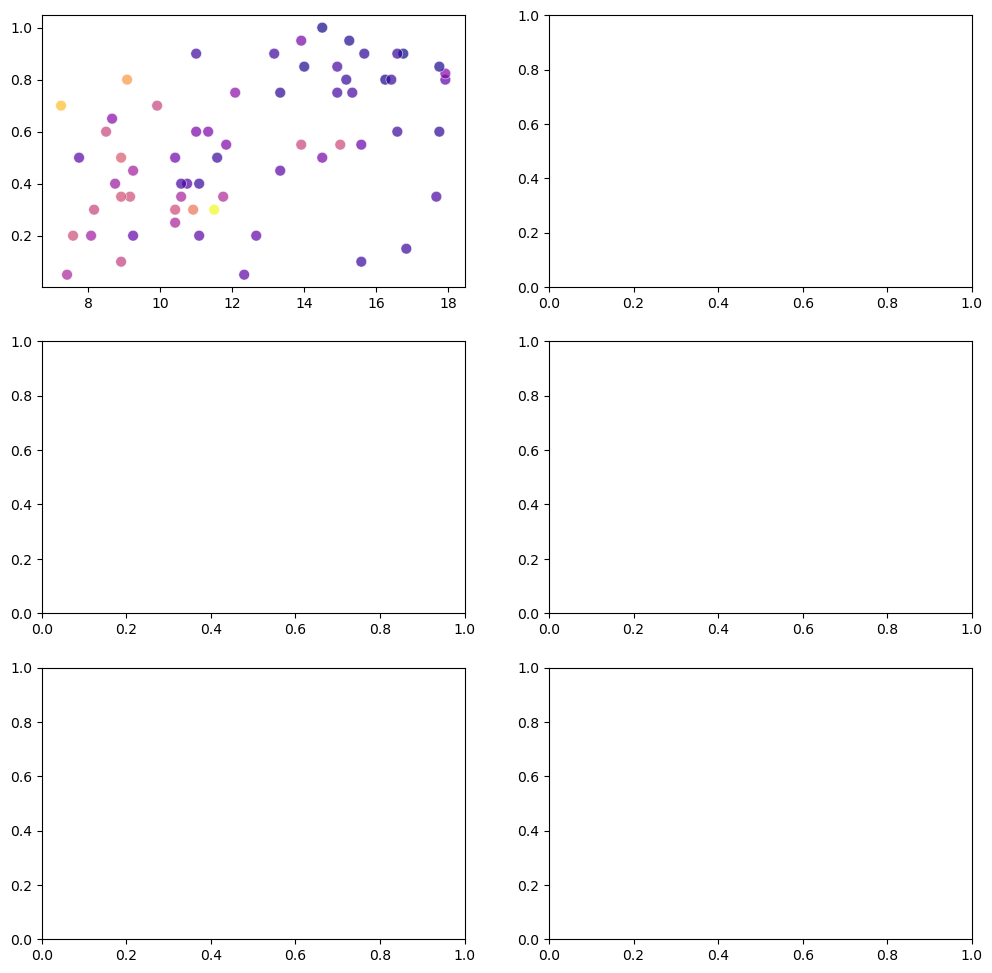

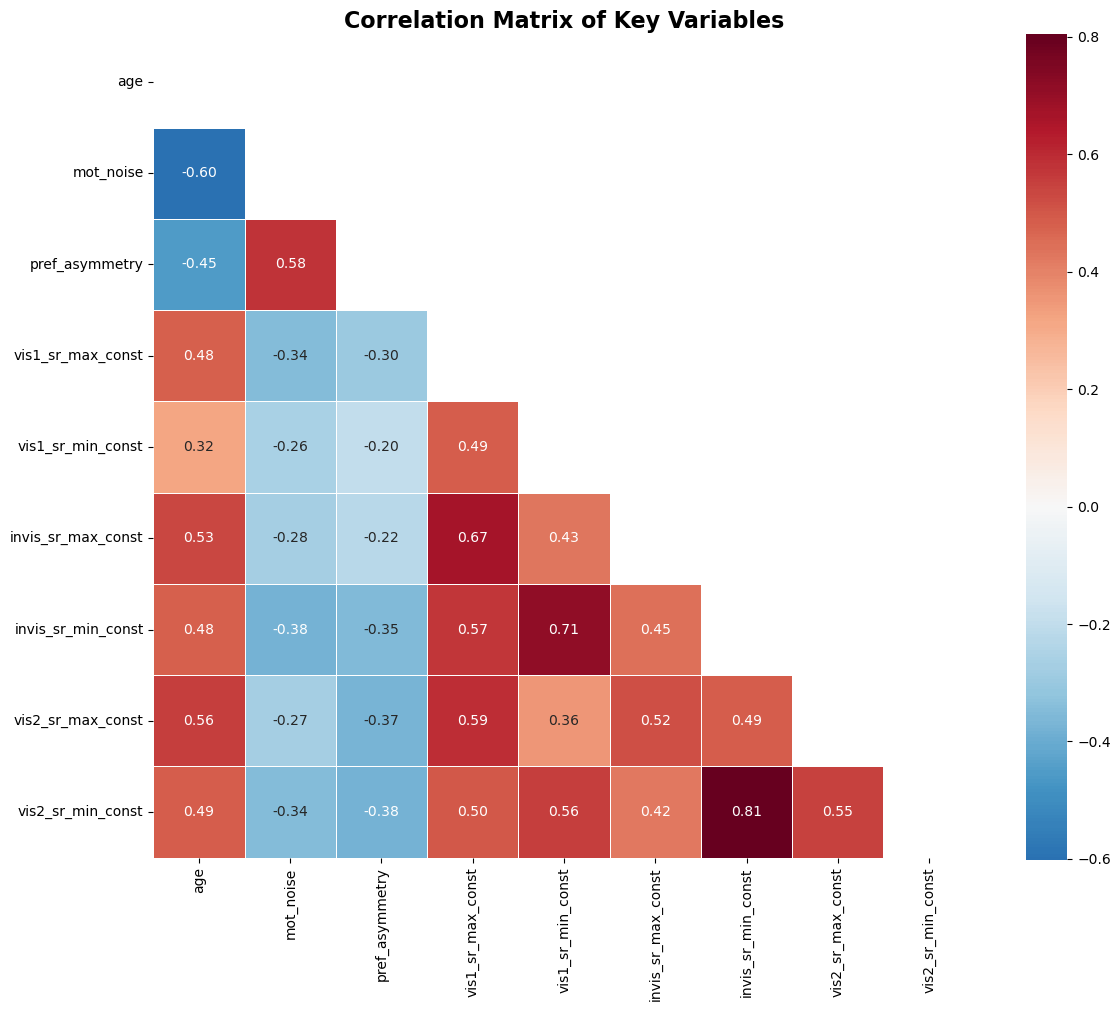

In [44]:

analysis = run_motor_learning_analysis(
    metadata_path='muh_metadata.csv',
    data_root_dir='muh_data/',
    output_dir='analysis_output'
)

metadata_path='muh_metadata.csv'

# Or step-by-step with more control
analysis = (MotorLearningAnalysis()
    .load_data(metadata_path, data_root_dir)
    .filter_data(required_trial_types=['vis1', 'invis', 'vis2'])
    .calculate_metrics()
    .run_analysis())
